In [1]:
%matplotlib inline
#Reference from https://pytorch.org/

In [2]:
from __future__ import print_function, division

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
from torch.nn import Tanh, Linear, ReLU, Sequential, Conv2d, MaxPool2d, Sigmoid, BatchNorm2d, Flatten, ConvTranspose2d

plt.ion()   # interactive mode

In [3]:
# Data augmentation and normalization for training
# Just normalization for validation
'''
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
'''
data_transforms = {
    'train': transforms.Compose([
        #transforms.RandomResizedCrop(224),
        transforms.Resize([224, 224]),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(180),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize([224, 224]),
        #transforms.Resize(256),
        #transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


data_transforms = {
    'train': transforms.Compose([
        transforms.Resize([224, 224]),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(180),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize([224, 224]),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


data_dir = '../AddMoreData061823/Class3/TTV'
l = []
l.append(datasets.ImageFolder(os.path.join(data_dir, 'train'), data_transforms['train']))
l.append(datasets.ImageFolder(os.path.join(data_dir, 'train'), data_transforms['train']))
l.append(datasets.ImageFolder(os.path.join(data_dir, 'train'), data_transforms['train']))
l.append(datasets.ImageFolder(os.path.join(data_dir, 'train'), data_transforms['train']))
#l.append(datasets.ImageFolder(os.path.join(data_dir, 'test'), data_transforms['test']))
image_datasetss = torch.utils.data.ConcatDataset(l)
image_datasets = {}
image_datasets['train'] = image_datasetss
image_datasets['test'] = datasets.ImageFolder(os.path.join(data_dir, 'test'), data_transforms['test'])
image_datasets['val'] = datasets.ImageFolder(os.path.join(data_dir, 'val'), data_transforms['test'])
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=5,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'test', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'test', 'val']}
class_names = image_datasets['test'].classes
print(class_names)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(len( image_datasets['train']))
print(len( image_datasets['val']))
print(len( image_datasets['test']))

['0', '1', '2']
3016
93
98


Visualize a few images
^^^^^^^^^^^^^^^^^^^^^^
Let's visualize a few training images so as to understand the data
augmentations.



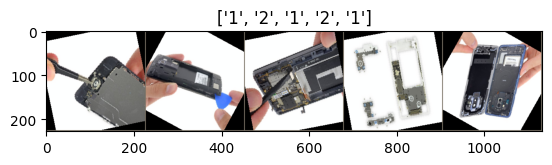

In [4]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [5]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs+1):
        print('Epoch {}/{}'.format(epoch+1, num_epochs))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    #print(outputs.shape)
                    #print(outputs)
                    #print(labels)
                    loss = criterion(outputs, labels)
    
                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            # deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model

Visualizing the model predictions
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Generic function to display predictions for a few images




In [6]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['test']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            m = nn.Softmax(dim=1)
            proOutput = m(outputs)
            pros = proOutput.detach().cpu().numpy()
            #print(pros)
            #_, preds = torch.max(outputs, 1)
            #pro = torch.max(proOutput, dim=1)[0]
            #_, predsmin = torch.min(outputs, 1)
            #promin = torch.min(proOutput, dim=1)[0]

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                #ax.set_title('predicted: %s with %s probabilities' %(class_names[preds[j]], round(pro[j].item(),4)))
                print('Actual label: %s' %(class_names[labels[j].item()]))
                for jj in range(3):
                    print('predicted: %s with %s probabilities' %(class_names[jj], round(pros[j][jj],4)))
                #print('predicted: %s with %s probabilities' %(class_names[1], round(pros[j][1],4)))
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
                
        model.train(mode=was_training)

#visualize_model(model_ft)

In [7]:
model_ft = models.resnet50(pretrained=True) #load googlenet.

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

print(model_ft)

C:\Users\haoyuliao\Anaconda3\envs\pytorch3\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\haoyuliao\Anaconda3\envs\pytorch3\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [8]:
class Res50(nn.Module):
    def __init__(self):
        super(Res50, self).__init__()
        self.conv1 = model_ft.conv1
        self.bn1 = model_ft.bn1
        self.relu = model_ft.relu
        self.maxpool = model_ft.maxpool
        self.layer1 = model_ft.layer1
        self.layer2 = model_ft.layer2
        self.layer3 = model_ft.layer3
        self.layer4 = model_ft.layer4
        self.avgpool = model_ft.avgpool
        self.fc = nn.Linear(2048 ,3)
        
        
    def forward(self, x):
        # Pass data through conv1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1) 
        x = self.fc(x)

        return x

class Res50_1layer(nn.Module):
    def __init__(self):
        super(Res50_1layer, self).__init__()
        self.conv1 = model_ft.conv1
        self.bn1 = model_ft.bn1
        self.relu = model_ft.relu
        self.maxpool = model_ft.maxpool
        self.layer1 = model_ft.layer1
        self.avgpool = model_ft.avgpool
        self.fc = nn.Linear(256 ,3)
        
        
    def forward(self, x):
        # Pass data through conv1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1) 
        x = self.fc(x)

        return x

class Res50_2layers(nn.Module):
    def __init__(self):
        super(Res50_2layers, self).__init__()
        self.conv1 = model_ft.conv1
        self.bn1 = model_ft.bn1
        self.relu = model_ft.relu
        self.maxpool = model_ft.maxpool
        self.layer1 = model_ft.layer1
        self.layer2 = model_ft.layer2
        self.avgpool = model_ft.avgpool
        self.fc = nn.Linear(512 ,3)
        
        
    def forward(self, x):
        # Pass data through conv1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1) 
        x = self.fc(x)

        return x

class Res50_3layers(nn.Module):
    def __init__(self):
        super(Res50_3layers, self).__init__()
        self.conv1 = model_ft.conv1
        self.bn1 = model_ft.bn1
        self.relu = model_ft.relu
        self.maxpool = model_ft.maxpool
        self.layer1 = model_ft.layer1
        self.layer2 = model_ft.layer2
        self.layer3 = model_ft.layer3
        self.avgpool = model_ft.avgpool
        self.fc = nn.Linear(1024 ,3)
        
        
    def forward(self, x):
        # Pass data through conv1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1) 
        x = self.fc(x)

        return x
    
#Res = Res50_1layer()
Res = Res50_2layers()
#Res = Res50_3layers()
Res = Res.to(device)
print(Res)

Res50_2layers(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stri

Train and evaluate
^^^^^^^^^^^^^^^^^^

It should take around 15-25 min on CPU. On GPU though, it takes less than a
minute.




In [9]:
ep = 100
model_ft = train_model(Res, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=ep)

Epoch 1/100
----------
train Loss: 0.8970 Acc: 0.7241
val Loss: 0.7992 Acc: 0.7312

Epoch 2/100
----------
train Loss: 0.7916 Acc: 0.7241
val Loss: 0.7663 Acc: 0.7312

Epoch 3/100
----------
train Loss: 0.7789 Acc: 0.7241
val Loss: 0.7603 Acc: 0.7312

Epoch 4/100
----------
train Loss: 0.7753 Acc: 0.7241
val Loss: 0.7550 Acc: 0.7312

Epoch 5/100
----------
train Loss: 0.7723 Acc: 0.7241
val Loss: 0.7469 Acc: 0.7312

Epoch 6/100
----------
train Loss: 0.7688 Acc: 0.7241
val Loss: 0.7375 Acc: 0.7312

Epoch 7/100
----------
train Loss: 0.7640 Acc: 0.7241
val Loss: 0.7251 Acc: 0.7312

Epoch 8/100
----------
train Loss: 0.7608 Acc: 0.7241
val Loss: 0.7254 Acc: 0.7312

Epoch 9/100
----------
train Loss: 0.7611 Acc: 0.7241
val Loss: 0.7239 Acc: 0.7312

Epoch 10/100
----------
train Loss: 0.7621 Acc: 0.7241
val Loss: 0.7223 Acc: 0.7312

Epoch 11/100
----------
train Loss: 0.7608 Acc: 0.7241
val Loss: 0.7219 Acc: 0.7312

Epoch 12/100
----------
train Loss: 0.7587 Acc: 0.7241
val Loss: 0.7197 Ac

val Loss: 0.7165 Acc: 0.7312

Epoch 98/100
----------
train Loss: 0.7591 Acc: 0.7241
val Loss: 0.7170 Acc: 0.7312

Epoch 99/100
----------
train Loss: 0.7586 Acc: 0.7241
val Loss: 0.7178 Acc: 0.7312

Epoch 100/100
----------
train Loss: 0.7588 Acc: 0.7241
val Loss: 0.7169 Acc: 0.7312

Epoch 101/100
----------
train Loss: 0.7577 Acc: 0.7241
val Loss: 0.7178 Acc: 0.7312

Training complete in 38m 31s
Best val Acc: 0.731183


Actual label: 0
predicted: 0 with 0.2 probabilities
predicted: 1 with 0.614 probabilities
predicted: 2 with 0.186 probabilities


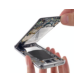

Actual label: 2
predicted: 0 with 0.2072 probabilities
predicted: 1 with 0.5986 probabilities
predicted: 2 with 0.1942 probabilities


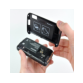

Actual label: 1
predicted: 0 with 0.2127 probabilities
predicted: 1 with 0.5869 probabilities
predicted: 2 with 0.2004 probabilities


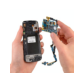

Actual label: 1
predicted: 0 with 0.2 probabilities
predicted: 1 with 0.6119 probabilities
predicted: 2 with 0.1881 probabilities


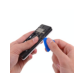

Actual label: 1
predicted: 0 with 0.2054 probabilities
predicted: 1 with 0.6054 probabilities
predicted: 2 with 0.1892 probabilities


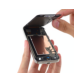

Actual label: 1
predicted: 0 with 0.1988 probabilities
predicted: 1 with 0.6135 probabilities
predicted: 2 with 0.1877 probabilities


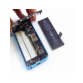

Actual label: 2
predicted: 0 with 0.214 probabilities
predicted: 1 with 0.5918 probabilities
predicted: 2 with 0.1942 probabilities


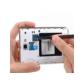

Actual label: 0
predicted: 0 with 0.2222 probabilities
predicted: 1 with 0.5794 probabilities
predicted: 2 with 0.1985 probabilities


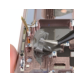

Actual label: 1
predicted: 0 with 0.1934 probabilities
predicted: 1 with 0.6266 probabilities
predicted: 2 with 0.18 probabilities


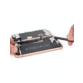

Actual label: 2
predicted: 0 with 0.2131 probabilities
predicted: 1 with 0.5822 probabilities
predicted: 2 with 0.2047 probabilities


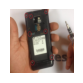

In [10]:
visualize_model(model_ft, 10)

In [11]:
correct = 0
total = 0
nb_classes = 3
confusion_matrix = torch.zeros(nb_classes, nb_classes)
with torch.no_grad():
    for data in dataloaders['train']:
        images, labels = data[0].cuda(), data[1].cuda()
        outputs = model_ft(images)
        predicted = torch.round(outputs)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        for t, p in zip(labels.view(-1), predicted.view(-1)):
                confusion_matrix[t.long(), p.long()] += 1
        

print('Accuracy of the network on the %s train images: %d %%' % (total,
    100 * correct / total))

print(confusion_matrix)
b= torch.sum(confusion_matrix, dim=1)
print(confusion_matrix/torch.reshape(b, (-1, 1))) #Normalizing


Accuracy of the network on the 3016 train images: 72 %
tensor([[   0.,  400.,    0.],
        [   0., 2184.,    0.],
        [   0.,  432.,    0.]])
tensor([[0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.]])


In [12]:
correct = 0
total = 0
nb_classes = 3
confusion_matrix = torch.zeros(nb_classes, nb_classes)
with torch.no_grad():
    for data in dataloaders['val']:
        images, labels = data[0].cuda(), data[1].cuda()
        outputs = model_ft(images)
        predicted = torch.round(outputs)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        for t, p in zip(labels.view(-1), predicted.view(-1)):
                confusion_matrix[t.long(), p.long()] += 1
        

print('Accuracy of the network on the %s val images: %d %%' % (total,
    100 * correct / total))

print(confusion_matrix)
b= torch.sum(confusion_matrix, dim=1)
print(confusion_matrix/torch.reshape(b, (-1, 1))) #Normalizing


Accuracy of the network on the 93 val images: 73 %
tensor([[ 0., 12.,  0.],
        [ 0., 68.,  0.],
        [ 0., 13.,  0.]])
tensor([[0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.]])


In [13]:
correct = 0
total = 0
nb_classes = 3
confusion_matrix = torch.zeros(nb_classes, nb_classes)
with torch.no_grad():
    for data in dataloaders['test']:
        images, labels = data[0].cuda(), data[1].cuda()
        outputs = model_ft(images)
        predicted = torch.round(outputs)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        for t, p in zip(labels.view(-1), predicted.view(-1)):
                confusion_matrix[t.long(), p.long()] += 1
        

print('Accuracy of the network on the %s test images: %d %%' % (total,
    100 * correct / total))

print(confusion_matrix)
b= torch.sum(confusion_matrix, dim=1)
print(confusion_matrix/torch.reshape(b, (-1, 1))) #Normalizing


Accuracy of the network on the 98 test images: 70 %
tensor([[ 0., 14.,  0.],
        [ 0., 69.,  0.],
        [ 0., 15.,  0.]])
tensor([[0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.]])


In [14]:
if not os.path.exists('trained models'):
   os.makedirs('trained models')
PATH = './trained models/Res50_2layers-TTVClass3-BestEP%s.pth' %(ep)
torch.save(model_ft.state_dict(), PATH)